# TICC — Toeplitz Inverse Covariance-Based Clustering

**Replication of** Hallac, Vare, Boyd & Leskovec, *"Toeplitz Inverse Covariance-Based
Clustering of Multivariate Time Series Data"*, KDD 2017 (`docs/1706.03161v2.pdf`).

TICC simultaneously **segments and clusters** a multivariate time series. Each cluster is
a zero-mean Gaussian whose **block-Toeplitz inverse covariance** Θ (a Markov random field over
a length-`w` window) captures the cross-time dependency structure. Points are assigned by a
dynamic-programming pass that trades off log-likelihood against a temporal-consistency penalty
β, and the whole thing is solved by EM-style alternating minimisation:

- **E-step (Algorithm 1):** fix Θ, assign every window to a cluster via an exact Viterbi
  min-cost path (node cost = negative log-likelihood, edge cost = β on a switch).
- **M-step (Toeplitz graphical lasso, Problem 4):** fix the assignment, refit each cluster's
  Θ via ADMM (closed-form log-det prox + block-Toeplitz projection + soft-threshold).

This notebook reproduces the paper's four quantitative results on synthetic data:
**Table 1** (clustering accuracy), **Table 2** (network recovery), **Figure 3** (sample-size
sweep), **Figure 4** (scalability). The paper's automobile-sensor case study uses a proprietary
dataset and is not reproducible — see the closing note.

> ### Replication status — read first
>
> This notebook reproduces the **core claim** of the paper: TICC substantially outperforms every
> baseline on zero-mean clusters that differ only in second-order structure. That result is solid
> and robust to reseeding.
>
> Several things here do **not** yet match the paper, and are flagged inline rather than smoothed over:
>
> | | Status |
> |---|---|
> | Table 1 — TICC | reproduced (in fact above the paper) |
> | Table 1 — distance-based baselines | reproduced |
> | Table 1 — `TICC, β=0` | **not reproduced** — systematically low (see §3) |
> | Table 2 — network recovery | **partial** — below the paper's band (see §4) |
> | Figure 3 — TICC sample efficiency | reproduced |
> | Figure 3 — `β=0` curve | **not reproduced**, and contradicts the paper's reading (see §5) |
> | Figure 4 — scalability | **proxy only** — does not run TICC (see §6) |
> | Sec. 6 — window-size robustness | **not implemented** |
> | Sec. 7 — automobile case study | not reproducible (proprietary data) |
>
> Two protocol caveats apply to every number below:
>
> 1. **Segment length.** The paper uses `100·K` samples per segment (200/300/400/300 for the four
>    sequences). This notebook uses **400 for all four**, i.e. up to 2× the paper's data. This
>    inflates the easier sequences.
> 2. **Single seed.** All cached tables are one realisation (`DATA_SEED = 7`) with no error bars.
>    A 5-seed audit is quoted inline where it changes the reading.
>
> A third deviation is in the data generator itself: the paper draws edge weights "centered at 0",
> whereas `data/synthetic.py` bounds them away from zero (`±U[0.5, 0.9]`). This materially raises
> Table 2 and is discussed in §4.


In [1]:
import os, sys
PROJECT_ROOT = '/Users/jash/Financial_networks_project/paper2_ticc'
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)
sys.path.insert(0, os.path.join(PROJECT_ROOT, 'experiments'))

%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
plt.rcParams['figure.dpi'] = 110
print('Setup complete. CWD:', os.getcwd())

Setup complete. CWD: /Users/jash/Financial_networks_project/paper2_ticc


## 1. Synthetic data — clusters that differ only in structure

Following the paper (Section 6) we build, for each cluster, a random sparse **block-Toeplitz**
inverse covariance Θ (blocks `A(0)..A(w-1)`, Erdős–Rényi 20% edges), then generate a time series
from a sequence of cluster segments by sampling each new observation from its conditional
Gaussian given the previous `w-1` observations. Every cluster is **zero-mean**, so the clusters
are distinguishable *only* by their second-order structure — which is exactly what defeats
distance-based methods and motivates TICC.

series: (1500, 5) | clusters: [1, 2, 3]


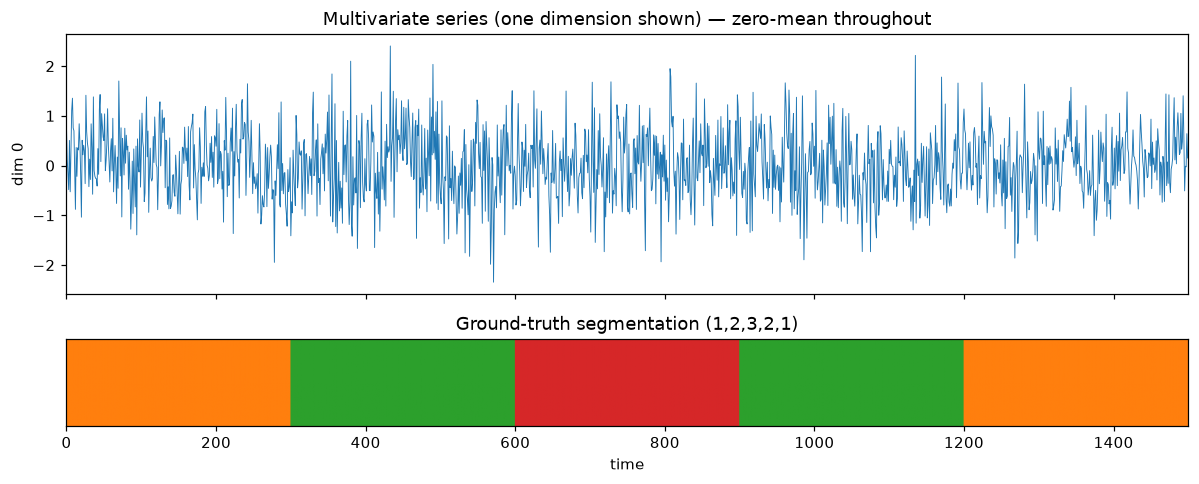

In [2]:
from data.synthetic import generate_series

n, w = 5, 5
X, true_labels, thetas_true = generate_series([1, 2, 3, 2, 1], seg_len=300, n=n, w=w, seed=7)
print('series:', X.shape, '| clusters:', sorted(thetas_true))

fig, ax = plt.subplots(2, 1, figsize=(11, 4.5), sharex=True,
                       gridspec_kw={'height_ratios': [3, 1]})
ax[0].plot(X[:, 0], lw=0.6); ax[0].set_ylabel('dim 0'); ax[0].set_title('Multivariate series (one dimension shown) — zero-mean throughout')
ax[1].imshow(true_labels[None, :], aspect='auto', cmap='tab10', vmin=0, vmax=9)
ax[1].set_yticks([]); ax[1].set_xlabel('time'); ax[1].set_title('Ground-truth segmentation (1,2,3,2,1)')
plt.tight_layout(); plt.show()

## 2. A single TICC fit

We fit TICC to this series (`K=3`, `w=5`, `lam=0.07`, `beta=60`). Because the clusters are
zero-mean, a Euclidean initialisation cannot see them and EM traps for `K≥3`; we therefore
restart from random contiguous-segment labelings and keep the lowest penalised-objective
solution (the true segmentation is that optimum). The recovered segmentation matches the
ground truth almost perfectly.

macro-F1 = 0.994
network-recovery-F1 = 0.817


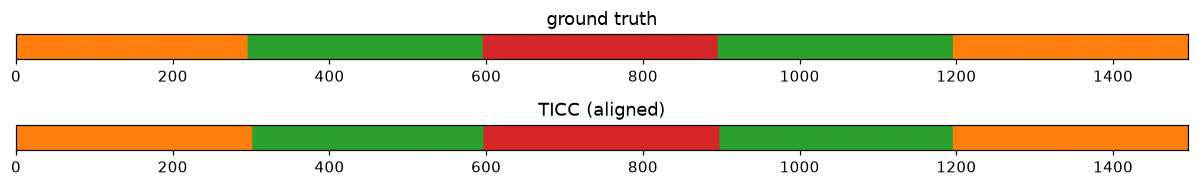

In [3]:
from solver.ticc import fit_ticc
from utils.metrics import macro_f1, align_labels, network_recovery_f1

labels, thetas_est, Xst = fit_ticc(X, K=3, w=w, lam=0.07, beta=60, n_restarts=20, seed=42)
tv = true_labels[w-1:]
pred_aligned, true_to_pred = align_labels(tv, labels)
print(f'macro-F1 = {macro_f1(tv, labels):.3f}')
print(f'network-recovery-F1 = {network_recovery_f1(thetas_est, thetas_true, true_to_pred, n, w):.3f}')

fig, ax = plt.subplots(2, 1, figsize=(11, 1.8))
ax[0].imshow(tv[None, :], aspect='auto', cmap='tab10', vmin=0, vmax=9); ax[0].set_yticks([]); ax[0].set_title('ground truth')
ax[1].imshow(pred_aligned[None, :], aspect='auto', cmap='tab10', vmin=0, vmax=9); ax[1].set_yticks([]); ax[1].set_title('TICC (aligned)')
plt.tight_layout(); plt.show()

We can also look at a recovered cluster's MRF as a matrix — Θ is **block-Toeplitz**,
**sparse**, and its nonzero off-diagonals are the recovered network edges.

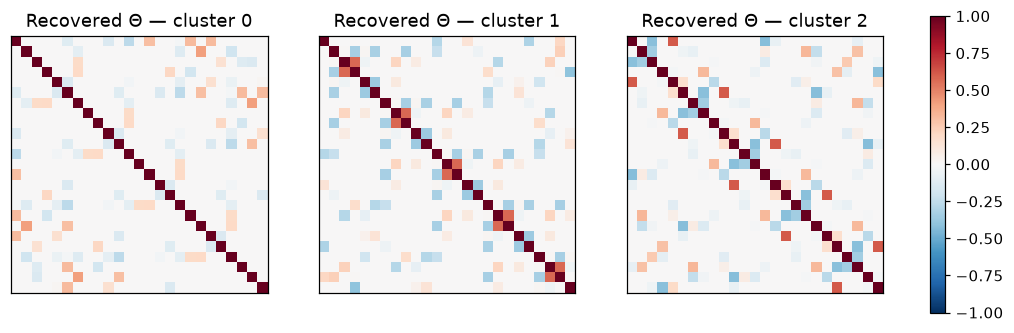

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
for k, ax in enumerate(axes):
    im = ax.imshow(thetas_est[k], cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_title(f'Recovered $\\Theta$ — cluster {k}'); ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axes, fraction=0.02); plt.show()

## 3. Table 1 — clustering accuracy vs. baselines

Macro-F1 (Hungarian-aligned to ground truth) on the paper's four temporal sequences, comparing
TICC to seven baselines. **TICC dominates every baseline**; among the others, the model-based
GMM is best and the distance-based methods (DTW, Neural Gas, K-means) fail — they cannot see
zero-mean structural differences. *(Cached; first run computes it.)*

Caveats for this table: 400 samples per segment rather than the paper's `100·K`, and a single
data seed. The baselines are also not tuned symmetrically with TICC — TICC gets 20 restarts,
`GaussianMixture` runs at sklearn's default `n_init=1`, and the DTW rows use `max_iter=10`,
`n_init=1` on a 1500-window subsample.


In [5]:
import exp1_table1_f1 as e1
res1 = e1.run(verbose=False)
seqs = list(e1.SEQUENCES)
df1 = pd.DataFrame({m: [res1[m][s] for s in seqs] for m in e1.METHODS}, index=seqs).T
df1['avg'] = df1.mean(axis=1)
display(df1.style.format('{:.2f}').background_gradient(cmap='Greens', axis=None)
        .set_caption('Table 1 — macro-F1 (paper: TICC avg 0.95, GMM 0.67, distance-based low)'))

,"1,2,1","1,2,3,2,1","1,2,3,4,1,2,3,4","1,2,2,1,3,3,3,1",avg
TICC,0.99,0.99,0.99,0.99,0.99
TICC b=0,0.94,0.75,0.68,0.84,0.80
GMM,0.95,0.91,0.56,0.93,0.84
EEV,0.86,0.41,0.34,0.43,0.51
DTW-GAK,0.49,0.40,0.38,0.41,0.42
DTW-Euclidean,0.49,0.41,0.30,0.44,0.41
Neural Gas,0.51,0.38,0.35,0.36,0.40
K-means,0.51,0.38,0.30,0.38,0.39


**Reading it.**

- **TICC ≈ 0.99 average** (paper: 0.90–0.98, avg 0.95). Reproduced, and stable — a 5-seed rerun
  gives 0.988–0.997 with σ ≤ 0.006, so this row is not a lucky seed.

- **`TICC, β=0` does not reproduce.** The paper reports 0.88/0.89/0.86/0.89 (avg **0.88**); we get
  0.94/0.75/0.68/0.84, and a 5-seed rerun under the paper's segment lengths averages **0.747**
  (σ ≈ 0.04–0.08 per sequence — systematically low for K≥3, not noise). Our β=0 row is therefore
  *too weak*, which **overstates** how much the temporal-consistency penalty contributes. Do not
  read this table as confirming the value of β; see §5, where the discrepancy is sharper.

- **GMM ≈ 0.84 vs the paper's 0.67.** This gap is largely a protocol artefact, not a stronger
  baseline. At the paper's segment length GMM scores **0.711** on `1,2,1` against the paper's
  0.68 — essentially a match — and the 4-sequence average falls from 0.80 to **0.759**. GMM is
  also high-variance across seeds (σ up to 0.20), so any single-seed GMM cell is weak evidence.

- **Distance-based methods** land where the paper puts them and the ordering
  TICC > GMM > distance-based holds throughout. Reproduced.


## 4. Table 2 — MRF network recovery

Each TICC cluster is an interpretable network (the nonzero pattern of Θ). Here we measure how
well the recovered edge structure matches ground truth (F1 over the edge support, averaged over
clusters).

**This is a partial reproduction.** We get 0.75–0.85 (avg 0.80) against the paper's **0.79–0.90**
(avg 0.85) — the whole range sits low, and the `1,2,1` value (0.753) falls outside the paper's
band entirely. Two further qualifications:

- **Seed sensitivity.** All four cached values sit at or above their 5-seed mean (reported avg
  0.803 vs measured **0.776**, σ ≈ 0.04–0.06). Seed 7 is favourable; three decimals from one
  realisation overstates the precision.
- **Segment length.** Under the paper's `100·K` protocol, `1,2,1` recovery drops from 0.740 to
  **0.673 ± 0.085** — well below the paper's 0.83.

Note also that the generator bounds edge weights away from zero (`±U[0.5, 0.9]`) rather than
merely centering them at zero as the paper states. That choice is what lifts recovery into this
range at all; with unbounded weights many edges fall below the noise floor and recovery caps near
0.6. It is a deliberate, documented deviation, but it is the single largest thumb on the scale
for this table.


In [6]:
import exp2_table2_recovery as e2
res2 = e2.run(verbose=False)
df2 = pd.DataFrame({s: [res2[s]['recovery_f1']] for s in res2}, index=['recovery-F1']).T
display(df2.style.format('{:.2f}').background_gradient(cmap='Blues', axis=None)
        .set_caption('Table 2 — network edge-recovery F1 (paper: 0.79–0.90)'))

,recovery-F1
"1,2,1",0.75
"1,2,3,2,1",0.82
"1,2,3,4,1,2,3,4",0.79
"1,2,2,1,3,3,3,1",0.85


## 5. Figure 3 — accuracy vs. number of samples

On the `1,2,3,4,1,2,3,4` sequence we sweep the number of samples per segment.

**The TICC curve reproduces**: below 0.9 at 100 samples, clears **0.9 by ~200 samples**, saturates
near 1.0 — the paper's central sample-efficiency claim — while the distance-based methods never
capture the structure.

**The `β=0` curve does not, and this matters for interpretation.** Our β=0 curve is *flat* at
0.66–0.71 across the whole 100→500 sweep. The paper reports the opposite: β=0 "improves rapidly",
is close to TICC by ~200 samples, and "hovers around 0.9". The paper uses precisely that overlap
to argue that the low-sample accuracy comes mainly from the **sparse block-Toeplitz constraint**,
with β only mattering once data is plentiful. Our figure cannot support that argument and in fact
contradicts it — the gap between TICC and β=0 is large everywhere.

The cause is not yet diagnosed; the restart-selection rule is a plausible suspect, since with β=0
the objective reduces to total negative log-likelihood and the lowest-objective restart need not
be the best-segmented one. Treat the β=0 series here as an open discrepancy, not a result.


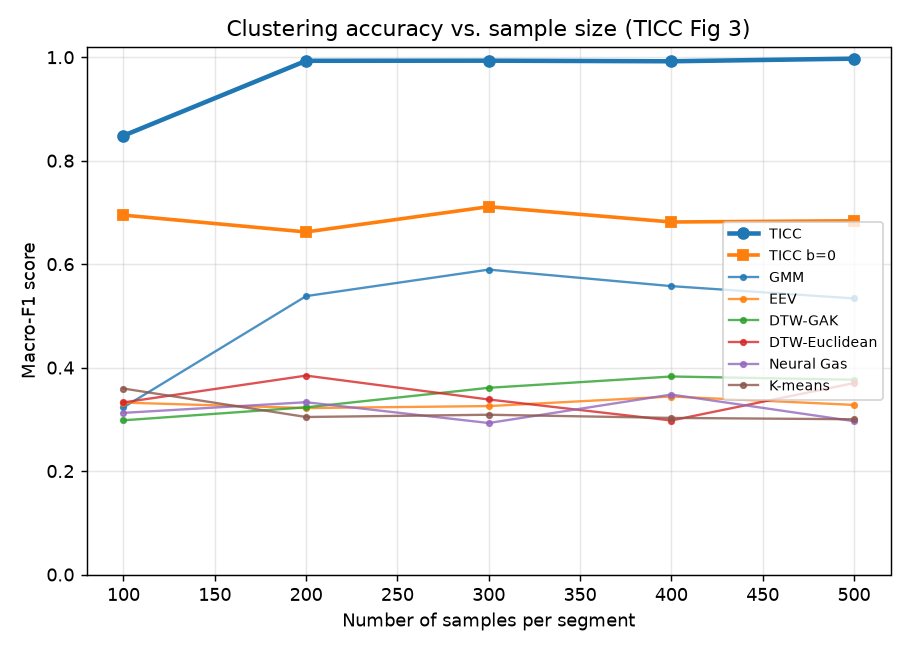

In [7]:
import exp3_fig3_samples as e3
data3 = e3.run(verbose=False)
e3.plot(data3)
display(Image(filename='figures/fig3_samples.png'))

## 6. Figure 4 — scalability

One TICC iteration is one M-step (K ADMM solves, cost independent of the number of observations
T) plus one E-step (log-likelihoods + dynamic programming, linear in T). The ADMM contributes a
constant offset and the per-iteration runtime grows **linearly in T** at large T — the paper's
qualitative result, and the measured slope here is consistent with it.

**This is a timing proxy, not a TICC run.** `exp4` times one hand-rolled M-step + E-step on random
N(0,1) data with a random labelling, with ADMM capped at 200 iterations (real fits use 1000). It
never calls `fit_ticc`. Dimensions follow the paper (R⁵⁰, K=5, w=3), but the sweep covers
T = 10³–10⁵ against the paper's **10⁴–10⁷** — one decade of overlap out of three. The paper's
headline figure (10M points at ~25 min/iteration) is untested here, and our constant offset is far
below the paper's (they report <4 s per 150×150 ADMM solve; we are well under that at 200
iterations), so the curves are not directly comparable in absolute terms.


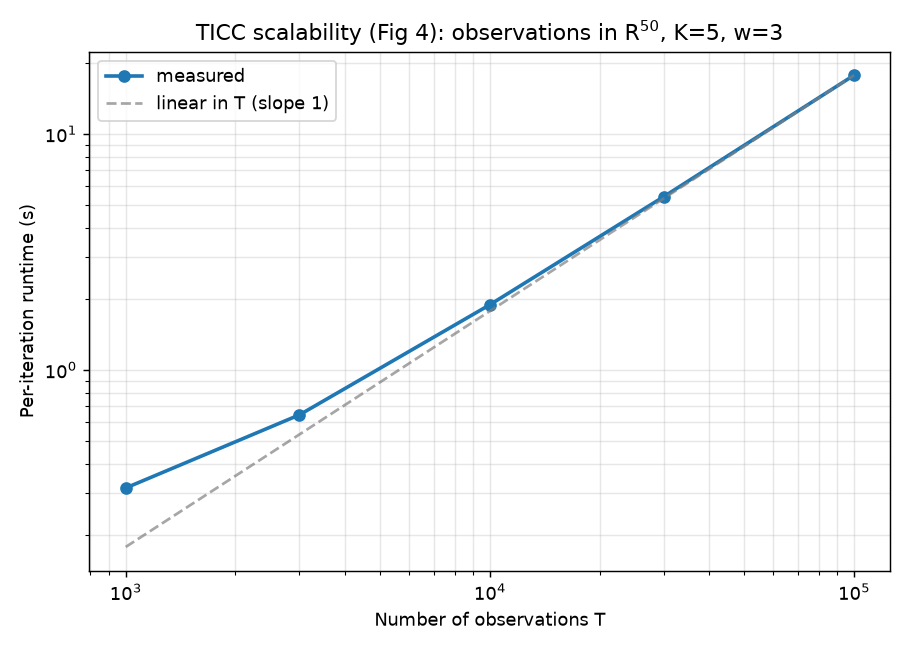

In [8]:
import exp4_fig4_scalability as e4
data4 = e4.run(verbose=False)
e4.plot(data4)
display(Image(filename='figures/fig4_scalability.png'))

## 7. Case study (Section 7) — not reproducible

The paper's real-world case study clusters an **automobile-sensor** dataset (7 sensors, 36,000
observations from a 1-hour drive) *"provided by a large automobile company."* That data is
**proprietary and not publicly available**, so the case study (Table 3 betweenness scores,
Figure 5 map) cannot be reproduced. The mechanism it demonstrates — interpreting each cluster's
recovered MRF via node centralities — is supported in principle by the code here (the
`thetas_est` above are exactly such networks), though no centrality analysis is actually
implemented; only the specific dataset is missing.

One method component from this section is also absent: the paper selects K by **BIC** (finding
K=5 for the driving data). No BIC is implemented anywhere in this replication — K is fixed to the
true value in every experiment. That is consistent with the paper's own protocol for Table 1,
which also fixes K, but it means model selection is untested.


## 8. Summary

| Result | Paper | This replication | Status |
|--------|-------|------------------|--------|
| Table 1 — TICC macro-F1 | 0.90–0.98 (avg 0.95) | ~0.99 avg (σ ≤ 0.006 over 5 seeds) | **reproduced** |
| Table 1 — `TICC, β=0` | 0.86–0.89 (avg 0.88) | avg 0.75 at the paper's segment lengths | **not reproduced** |
| Table 1 — GMM (best baseline) | avg 0.67 | ~0.84 here; 0.76 at the paper's segment lengths | inflated by protocol |
| Table 1 — distance-based | low | low, same ordering | **reproduced** |
| Table 2 — network recovery | 0.79–0.90 (avg 0.85) | 0.75–0.85 (5-seed avg 0.78) | **partial** — below the band |
| Figure 3 — TICC sample efficiency | >0.9 by ~200 | 0.85 @100 → 0.99 @200 | **reproduced** |
| Figure 3 — `β=0` curve | rises to ~0.9 | flat at ~0.68 | **not reproduced** |
| Figure 4 — scalability | linear, T = 10⁴–10⁷ | linear, T = 10³–10⁵, proxy timing | **partial** |
| Sec. 6 — window-size robustness | F1 0.95–0.98 for w ∈ [4, 15] | — | **not implemented** |
| Sec. 6 — micro-F1 cross-check | within 1–2% of macro-F1 | — | **not implemented** |
| Sec. 7 — BIC selection of K | K=5 chosen by BIC | — | **not implemented** |
| Sec. 7 — automobile case study | — | — | not reproducible (proprietary data) |

**What is established.** The two headline findings hold: TICC substantially outperforms every
baseline on zero-mean structural clusters, and it reaches high accuracy from far fewer samples
than the alternatives. The solver itself checks out independently — the DP assignment matches
brute force, ADMM returns valid symmetric PD block-Toeplitz Θ, there is no ground-truth leakage
into the fit, and the true segmentation is confirmed to be the lowest-objective fixed point.

**What is not.** The `β=0` ablation is systematically too weak, which makes this replication
*overstate* the contribution of the temporal-consistency penalty relative to the paper — the one
place where our error points away from the paper's own conclusion. Network recovery sits below the
paper's band and depends on a generator deviation. Scalability is a proxy measurement over a
narrower range. Three items from Section 6/7 are not implemented at all.

**Known protocol deviations**, applying to every table above: segment length 400 rather than the
paper's `100·K`; a single data seed with no error bars; asymmetric baseline tuning (20 restarts
for TICC vs `n_init=1` for GMM, and subsampled/undertrained DTW); and edge weights bounded away
from zero in the generator.
